In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [13]:
df = pd.read_csv("Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df = df.sort_values('Order Date')

In [5]:
sales_data = df.groupby('Order Date')['Sales'].sum().reset_index()

sales_data.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [6]:
sales_data['Days'] = (sales_data['Order Date'] - sales_data['Order Date'].min()).dt.days

In [7]:
X = sales_data[['Days']]
y = sales_data['Sales']

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
sales_data['Predicted Sales'] = model.predict(X)

sales_data.head()

,Order Date,Sales,Days,Predicted Sales
0,2014-01-03,16.448,0,1161.127098
1,2014-01-04,288.060,1,1162.057911
2,2014-01-05,19.536,2,1162.988724
3,2014-01-06,4407.100,3,1163.919537
4,2014-01-07,87.158,4,1164.850350


In [9]:
mae = mean_absolute_error(y, sales_data['Predicted Sales'])

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1525.6238656501828


In [10]:
future_days = np.arange(X['Days'].max()+1, X['Days'].max()+31).reshape(-1,1)

future_predictions = model.predict(future_days)

future_dates = pd.date_range(
    sales_data['Order Date'].max() + pd.Timedelta(days=1),
    periods=30
)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecasted Sales': future_predictions
})

forecast_df.head()

c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Date,Forecasted Sales
0,2017-12-31,2518.252508
1,2018-01-01,2519.183321
2,2018-01-02,2520.114134
3,2018-01-03,2521.044948
4,2018-01-04,2521.975761


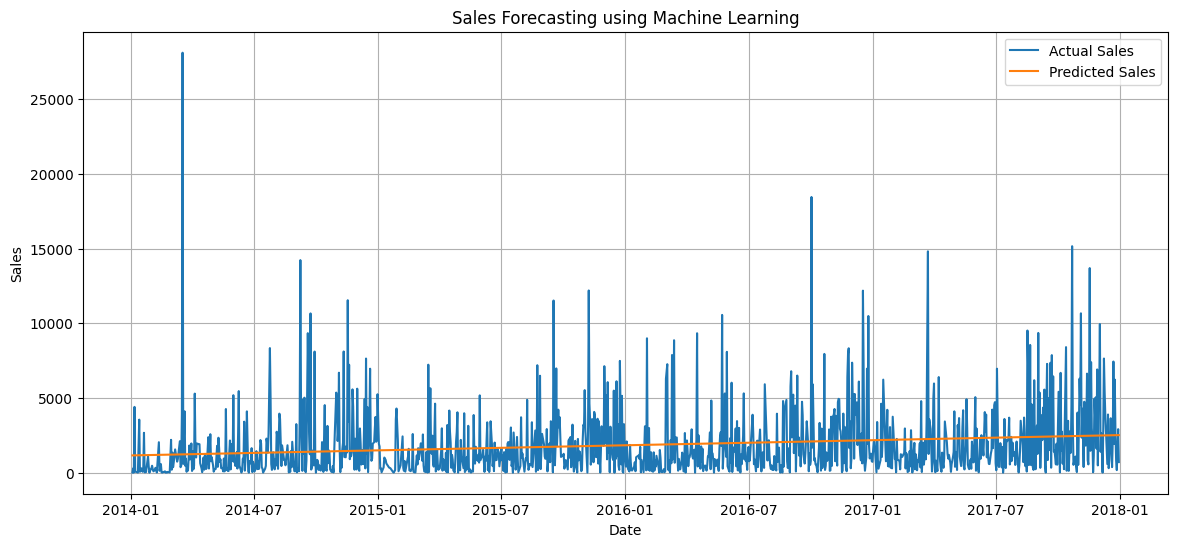

In [12]:
plt.figure(figsize=(14,6))

plt.plot(
    sales_data['Order Date'],
    sales_data['Sales'],
    label='Actual Sales'
)

plt.plot(
    sales_data['Order Date'],
    sales_data['Predicted Sales'],
    label='Predicted Sales'
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Forecasting using Machine Learning")
plt.legend()
plt.grid(True)

plt.show()

Conclusion

This project successfully forecasted future sales using historical business data. 
Machine learning regression techniques were used to analyze sales trends and generate future predictions. 
The project also included visualization and error evaluation for better business understanding.